# Data Transformation and Dimensionality Reduction

## Data Transformation Techniques

### Normalization (Min-Max Scaling)

In [1]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

data = pd.DataFrame({
    'A': [10, 20, 30, 40, 50],
    'B': [5, 15, 25, 35, 45]
})

scaler = MinMaxScaler()
normalized_data = scaler.fit_transform(data)
normalized_df = pd.DataFrame(normalized_data, columns=data.columns)

print(normalized_df)

      A     B
0  0.00  0.00
1  0.25  0.25
2  0.50  0.50
3  0.75  0.75
4  1.00  1.00


### Standardization (Z-score)

In [2]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
standardized_data = scaler.fit_transform(data)
standardized_df = pd.DataFrame(standardized_data, columns=data.columns)

print(standardized_df)

          A         B
0 -1.414214 -1.414214
1 -0.707107 -0.707107
2  0.000000  0.000000
3  0.707107  0.707107
4  1.414214  1.414214


## Encoding Categorical Variables

### Label Encoding

In [3]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

data_branch = pd.DataFrame({
    'Branch': ['CSE', 'ECE', 'MECH', 'CSE', 'ECE']
})

encoder = LabelEncoder()
data_branch['Encoded_Branch'] = encoder.fit_transform(data_branch['Branch'])

print(data_branch)

  Branch  Encoded_Branch
0    CSE               0
1    ECE               1
2   MECH               2
3    CSE               0
4    ECE               1


### One-Hot Encoding using Pandas

In [4]:
df_color = pd.DataFrame({'Color': ['Red', 'Blue', 'Green', 'Red', 'Blue']})
one_hot = pd.get_dummies(df_color, columns=['Color'])

print(one_hot)

   Color_Blue  Color_Green  Color_Red
0       False        False       True
1        True        False      False
2       False         True      False
3       False        False       True
4        True        False      False


### One-Hot Encoding using Scikit-Learn

In [5]:
from sklearn.preprocessing import OneHotEncoder

encoder_oh = OneHotEncoder()
result_oh = encoder_oh.fit_transform(data_branch[['Branch']]).toarray()

print(result_oh)

[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]]


### Scaling and Encoding on Tips Dataset

In [6]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler

tips = sns.load_dataset('tips')
print(tips.head())

numeric_cols = tips.select_dtypes(include=['float64', 'int64']).columns
scaler_minmax = MinMaxScaler()
tips_normalized = tips.copy()
tips_normalized[numeric_cols] = scaler_minmax.fit_transform(tips[numeric_cols])
print(tips_normalized.head())

scaler_standard = StandardScaler()
tips_standardized = tips.copy()
tips_standardized[numeric_cols] = scaler_standard.fit_transform(tips[numeric_cols])
print(tips_standardized.head())

tips_onehot = pd.get_dummies(tips, columns=['sex', 'smoker', 'day', 'time'])
print(tips_onehot.head())

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4
   total_bill       tip     sex smoker  day    time  size
0    0.291579  0.001111  Female     No  Sun  Dinner   0.2
1    0.152283  0.073333    Male     No  Sun  Dinner   0.4
2    0.375786  0.277778    Male     No  Sun  Dinner   0.4
3    0.431713  0.256667    Male     No  Sun  Dinner   0.2
4    0.450775  0.290000  Female     No  Sun  Dinner   0.6
   total_bill       tip     sex smoker  day    time      size
0   -0.314711 -1.439947  Female     No  Sun  Dinner -0.600193
1   -1.063235 -0.969205    Male     No  Sun  Dinner  0.453383
2    0.137780  0.363356    Male     No  Sun  Dinner  0.453383
3    0.438315  0.225754    Male     No  Sun  Dinner -0.600193
4    0.540745  0.4

## Dimensionality Reduction Techniques

### Principal Component Analysis (PCA)

[0.72627656 0.1730423 ]
        PC1       PC2
0 -1.348415  0.426746
1 -0.955740  1.093576
2  0.540971  0.122324
3  0.067789 -0.674616
4  1.408308  0.847661


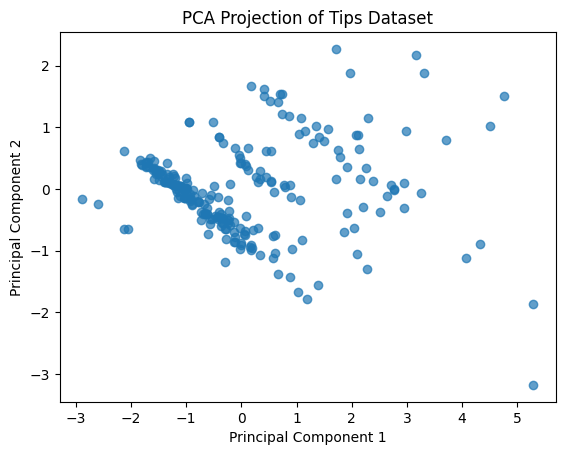

In [7]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

tips = sns.load_dataset('tips')
numeric_cols = tips.select_dtypes(include=['float64', 'int64'])

scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_cols)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'])
print(pca.explained_variance_ratio_)
print(pca_df.head())

plt.scatter(pca_df['PC1'], pca_df['PC2'], alpha=0.7)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Projection of Tips Dataset')
plt.show()

### Linear Discriminant Analysis (LDA)

[0.9912126 0.0087874]
        LD1       LD2  target
0  8.061800 -0.300421       0
1  7.128688  0.786660       0
2  7.489828  0.265384       0
3  6.813201  0.670631       0
4  8.132309 -0.514463       0


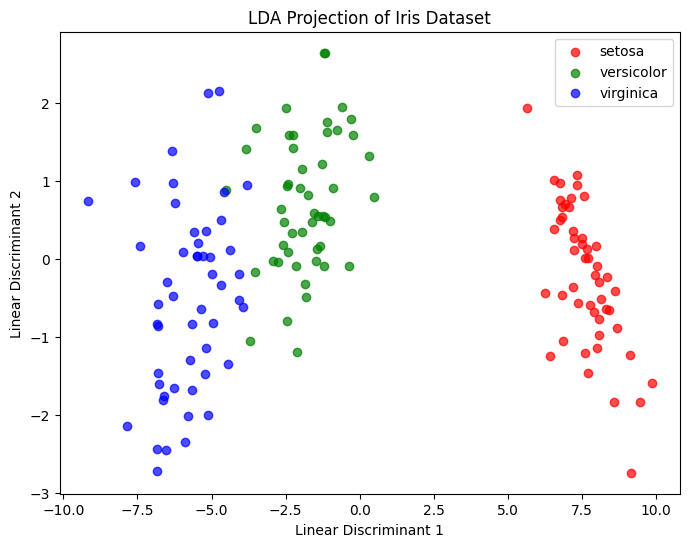

In [8]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import matplotlib.pyplot as plt

iris = load_iris()
X = iris.data
y = iris.target

lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X, y)

lda_df = pd.DataFrame(X_lda, columns=['LD1', 'LD2'])
lda_df['target'] = y

print(lda.explained_variance_ratio_)
print(lda_df.head())

plt.figure(figsize=(8, 6))
for label, color in zip([0, 1, 2], ['red', 'green', 'blue']):
    plt.scatter(
        lda_df.loc[lda_df['target'] == label, 'LD1'],
        lda_df.loc[lda_df['target'] == label, 'LD2'],
        label=iris.target_names[label],
        color=color,
        alpha=0.7
    )
plt.xlabel('Linear Discriminant 1')
plt.ylabel('Linear Discriminant 2')
plt.title('LDA Projection of Iris Dataset')
plt.legend()
plt.show()

### t-SNE (t-distributed Stochastic Neighbor Embedding)

       TSNE1     TSNE2  target
0 -25.502390 -1.643927       0
1 -23.042055 -0.994582       0
2 -22.787239 -2.096912       0
3 -22.498199 -1.861895       0
4 -25.574633 -2.148222       0


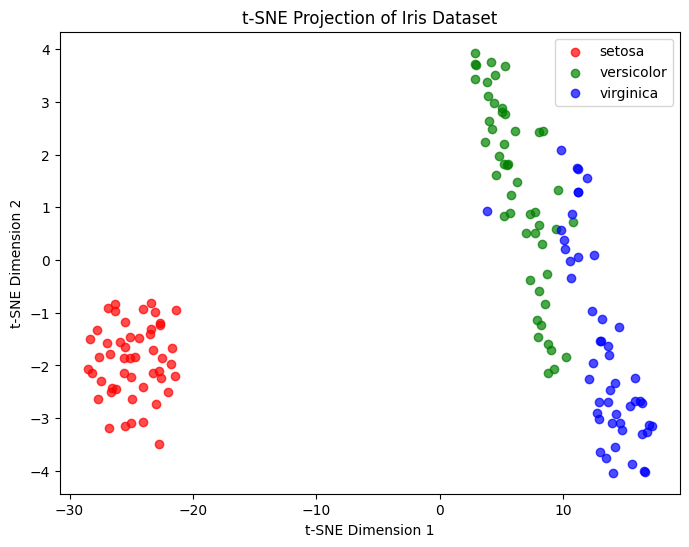

In [9]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

iris = load_iris()
X = iris.data
y = iris.target

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X)

tsne_df = pd.DataFrame(X_tsne, columns=['TSNE1', 'TSNE2'])
tsne_df['target'] = y

print(tsne_df.head())

plt.figure(figsize=(8, 6))
for label, color in zip([0, 1, 2], ['red', 'green', 'blue']):
    plt.scatter(
        tsne_df.loc[tsne_df['target'] == label, 'TSNE1'],
        tsne_df.loc[tsne_df['target'] == label, 'TSNE2'],
        label=iris.target_names[label],
        color=color,
        alpha=0.7
    )
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.title('t-SNE Projection of Iris Dataset')
plt.legend()
plt.show()